page 1 loaded.
page 2 loaded.
page 3 loaded.
page 4 loaded.
page 5 loaded.
page 6 loaded.
page 7 loaded.
page 8 loaded.
page 9 loaded.
page 10 loaded.
page 11 loaded.
page 12 loaded.
page 13 loaded.
page 14 loaded.
page 15 loaded.
page 16 loaded.
page 17 loaded.
page 18 loaded.
page 19 loaded.
page 20 loaded.
page 21 loaded.
page 22 loaded.
page 23 loaded.
page 24 loaded.
page 25 loaded.
page 26 loaded.
page 27 loaded.
page 28 loaded.
page 29 loaded.
page 30 loaded.
page 31 loaded.
page 32 loaded.
page 33 loaded.
page 34 loaded.
page 35 loaded.
page 36 loaded.
page 37 loaded.
page 38 loaded.
page 39 loaded.
page 40 loaded.
page 41 loaded.
page 42 loaded.
page 43 loaded.
page 44 loaded.
page 45 loaded.
page 46 loaded.
page 47 loaded.
page 48 loaded.
page 49 loaded.
page 50 loaded.
page 51 loaded.
page 52 loaded.
page 53 loaded.
page 54 loaded.
page 55 loaded.
page 56 loaded.
page 57 loaded.
page 58 loaded.
page 59 loaded.
page 60 loaded.
page 61 loaded.
page 62 loaded.
page 63 loaded.
p

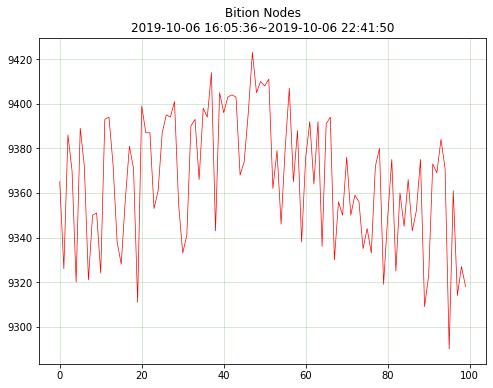

In [17]:
import requests
#원하는 사이트의 html 내용을 가져와 주는 역할
import time
#시간관련
import matplotlib.pyplot as plt
# 그래프 관련

nPage = 100
if nPage > 100:
    printf("요청 페이지가 너무 많아 시간이 오래 걸립니다.") 
    # 100이 넘었을 때 출력해주는 메시지
else:
    # 100이 넘지 않았을 때
    t = []
    n = []
    for page in range(1, nPage): 
        # 1부터 100 까지 반복 페이지당 100개씩 요청한다 Max = 100
        url = 'https://bitnodes.earn.com/api/v1/snapshots/?limit=100&page=' + str(page)
        resp = requests.get(url=url) #위 사이트를 request로 가져오고 resp 라는 변수에 저장 
        data = resp.json()
        print("page %d loaded." % page)

    
    for i in range(len(data['results'])):
        ts = time.gmtime(data['results'][i]['timestamp'])
        t.append(time.strftime("%Y-%m-%d %H:%M:%S", ts))
        n.append(data['results'][i]['total_nodes'])
        
t = t[::-1]
n = n[::-1]

#최근 노드수의 변화를 확인한다
plt.figure(figsize=(8,6))
plt.plot(n, color='red', linewidth=0.7)
plt.title('Bition Nodes\n' + t[0] + '~' + t[-1])
plt.grid(color='green', alpha=0.2)
plt.show()
        

In [44]:
import requests
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("금일 생성된 블록을 불러옵니다.")
url='https://blockchain.info/blocks?format=json'
resp = requests.get(url=url)
data = resp.json()

header = []
block = data['blocks']
for n in range(len(block)):
    height = block[n]['height']
    btime = block[n]['time']
    bhash = block[n]['hash']
    header.append([height, btime, bhash])
    
stime = btime - 24 * 60 * 60

for nDay in range(0,10):
    ts = time.gmtime(stime)
    date = time.strftime("%Y-%m-%d %H:%M:%S", ts)
    print("%s 생성된 블록을 읽어옵니다" % date)
                         
    url = 'https://blockchain.info/blocks/' + str(stime) + '000?format=json'
    resp = requests.get(url=url)
    data = resp.json()
                         
    for n in range(len(block)):
        height = block[n]['height']
        btime = block[n]['time']
        bhash = block[n]['hash']
        header.append([height, btime, bhash])
                         
    stime = block[0]['time'] - 24 * 60 * 60
                         
df = pd.DataFrame(header, columns=['Height','Time', 'Hash'])
sdf = df.sort_values('Time')
sdf = sdf.reset_index()
print('총 %d 개 블록 헤더를 읽어왔습니다.' %len(df))

금일 생성된 블록을 불러옵니다.
2019-11-06 00:03:10 생성된 블록을 읽어옵니다
2019-11-06 10:02:00 생성된 블록을 읽어옵니다
2019-11-06 10:02:00 생성된 블록을 읽어옵니다
2019-11-06 10:02:00 생성된 블록을 읽어옵니다
2019-11-06 10:02:00 생성된 블록을 읽어옵니다
2019-11-06 10:02:00 생성된 블록을 읽어옵니다
2019-11-06 10:02:00 생성된 블록을 읽어옵니다
2019-11-06 10:02:00 생성된 블록을 읽어옵니다
2019-11-06 10:02:00 생성된 블록을 읽어옵니다
2019-11-06 10:02:00 생성된 블록을 읽어옵니다
총 638 개 블록 헤더를 읽어왔습니다.
